# Câncer de Mama — Modelos de Machine Learning

Este notebook treina e avalia modelos de classificação para prever o desfecho (`Status`: Alive / Dead) de pacientes com câncer de mama. Ao final, o modelo com melhor desempenho é mantido para análise aprofundada.

**Modelos avaliados:**
- **Regressão Logística** — baseline interpretável, adequada para classificação binária com features codificadas
- **Random Forest** — robusto a outliers e dados mistos, suporta `class_weight='balanced'` para lidar com desbalanceamento
- **XGBoost** — gradient boosting com regularização, frequentemente supera Random Forest em dados tabulares

**Justificativa da escolha:**
O dataset possui 4.024 amostras com 11 features categóricas e 4 numéricas. Há desbalanceamento de classe (~85% Alive / ~15% Dead).  
A Regressão Logística serve como baseline interpretável. Random Forest e XGBoost são modelos de ensemble não-lineares e competitivos.  
Ambos os ensembles suportam SHAP e métricas voltadas para a classe minoritária (recall/F1), críticas em diagnóstico médico.

**Critério de seleção do melhor modelo:** F1-Score e ROC-AUC na classe Dead (positiva), pois em diagnóstico oncológico minimizar falsos negativos é prioritário.

## 1. Importações

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score, recall_score,
    accuracy_score, precision_score
)

from xgboost import XGBClassifier

import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
print("Imports OK")

Imports OK


## 2. Carregamento dos Dados

In [30]:
df = pd.read_csv('base/Breast_Cancer.csv')
df.columns = df.columns.str.strip()
df['Marital Status'] = df['Marital Status'].str.strip()

print(f"Shape: {df.shape}")
print(f"\nDistribuição do alvo:\n{df['Status'].value_counts()}")
print(f"\nProporção:\n{df['Status'].value_counts(normalize=True).round(3)}")
df.head()

Shape: (4024, 16)

Distribuição do alvo:
Status
Alive    3408
Dead      616
Name: count, dtype: int64

Proporção:
Status
Alive    0.847
Dead     0.153
Name: proportion, dtype: float64


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


## 3. Pré-processamento

### 3.1 Encode do alvo e separação de features

In [31]:
# Encode alvo: Alive=0, Dead=1
le = LabelEncoder()
y = le.fit_transform(df['Status'])   # Dead=1 é a classe positiva (risco)
print("Classes:", le.classes_, "→ índices:", list(range(len(le.classes_))))

# 'Survival Months' é removida: trata-se de dado prospectivo (quanto tempo
# o paciente viveu APÓS o diagnóstico). No momento do diagnóstico essa
# informação não existe — mantê-la causaria data leakage.
X = df.drop(columns=['Status', 'Survival Months'])
print("⚠️  'Survival Months' removida para evitar data leakage.")

# Separar colunas numéricas e categóricas
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"\nNuméricas ({len(num_cols)}): {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")

Classes: ['Alive' 'Dead'] → índices: [0, 1]
⚠️  'Survival Months' removida para evitar data leakage.

Numéricas (4): ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']
Categóricas (10): ['Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']


### 3.2 Pipeline de pré-processamento

In [32]:
from sklearn.preprocessing import OrdinalEncoder

# Encoder genérico para variáveis nominais/ordinais
# handle_unknown='use_encoded_value' evita erros no test set
cat_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
num_transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

print("Preprocessor criado.")

Preprocessor criado.


### 3.3 Divisão treino / teste (80/20 estratificado)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Dead no treino: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Dead no teste:  {y_test.sum()} ({y_test.mean():.1%})")

Treino: 3219 amostras | Teste: 805 amostras
Dead no treino: 493 (15.3%)
Dead no teste:  123 (15.3%)


## 4. Função de Avaliação

In [34]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    """Treina o pipeline e retorna métricas completas."""
    pipeline.fit(X_tr, y_tr)
    y_pred  = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1]

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    print(f"ROC-AUC : {roc_auc_score(y_te, y_proba):.4f}")

    # Cross-validation no conjunto de treino
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring='f1')
    print(f"CV F1 (5-fold, treino): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

    return pipeline, y_pred, y_proba

print("Função de avaliação definida.")

Função de avaliação definida.


## 5. Modelo 1 — Regressão Logística

**Por quê?** Modelo linear interpretável, eficiente para classificação binária.  
`class_weight='balanced'` compensa o desbalanceamento (~85/15).  
`max_iter=1000` garante convergência com features escaladas.

In [35]:
lr_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

lr_pipe, lr_pred, lr_proba = evaluate_model(
    "Regressão Logística", lr_pipeline, X_train, y_train, X_test, y_test
)

  Regressão Logística
              precision    recall  f1-score   support

       Alive       0.91      0.72      0.80       682
        Dead       0.28      0.59      0.38       123

    accuracy                           0.70       805
   macro avg       0.59      0.66      0.59       805
weighted avg       0.81      0.70      0.74       805

ROC-AUC : 0.7185
CV F1 (5-fold, treino): 0.4108 ± 0.0175


## 6. Modelo 2 — Random Forest

**Por quê?** Conjunto de árvores de decisão, não-linear, robusto a outliers e dados mistos.  
`class_weight='balanced_subsample'` aplica balanceamento em cada árvore.  
`n_estimators=300` oferece boa estabilidade sem custo excessivo.

In [36]:
rf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe, rf_pred, rf_proba = evaluate_model(
    "Random Forest", rf_pipeline, X_train, y_train, X_test, y_test
)

  Random Forest
              precision    recall  f1-score   support

       Alive       0.87      0.93      0.90       682
        Dead       0.38      0.23      0.29       123

    accuracy                           0.83       805
   macro avg       0.63      0.58      0.59       805
weighted avg       0.80      0.83      0.81       805

ROC-AUC : 0.6966
CV F1 (5-fold, treino): 0.3319 ± 0.0286


## 7. Modelo 3 — XGBoost

**Por quê?** Gradient boosting com regularização L1/L2, excelente em dados tabulares.  
`scale_pos_weight` compensa o desbalanceamento de classe passando a razão Alive/Dead.  
`eval_metric='logloss'` e `use_label_encoder=False` evitam warnings de versões recentes.

In [37]:
# Calcular scale_pos_weight: razão entre negativos e positivos no treino
# Equivalente ao class_weight='balanced' dos modelos sklearn
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos
print(f"scale_pos_weight = {neg}/{pos} = {scale_pw:.2f}")

xgb_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe, xgb_pred, xgb_proba = evaluate_model(
    "XGBoost", xgb_pipeline, X_train, y_train, X_test, y_test
)

scale_pos_weight = 2726/493 = 5.53
  XGBoost
              precision    recall  f1-score   support

       Alive       0.88      0.84      0.86       682
        Dead       0.29      0.37      0.32       123

    accuracy                           0.77       805
   macro avg       0.59      0.60      0.59       805
weighted avg       0.79      0.77      0.78       805

ROC-AUC : 0.6765
CV F1 (5-fold, treino): 0.3364 ± 0.0266


## 8. Comparação Visual dos Três Modelos

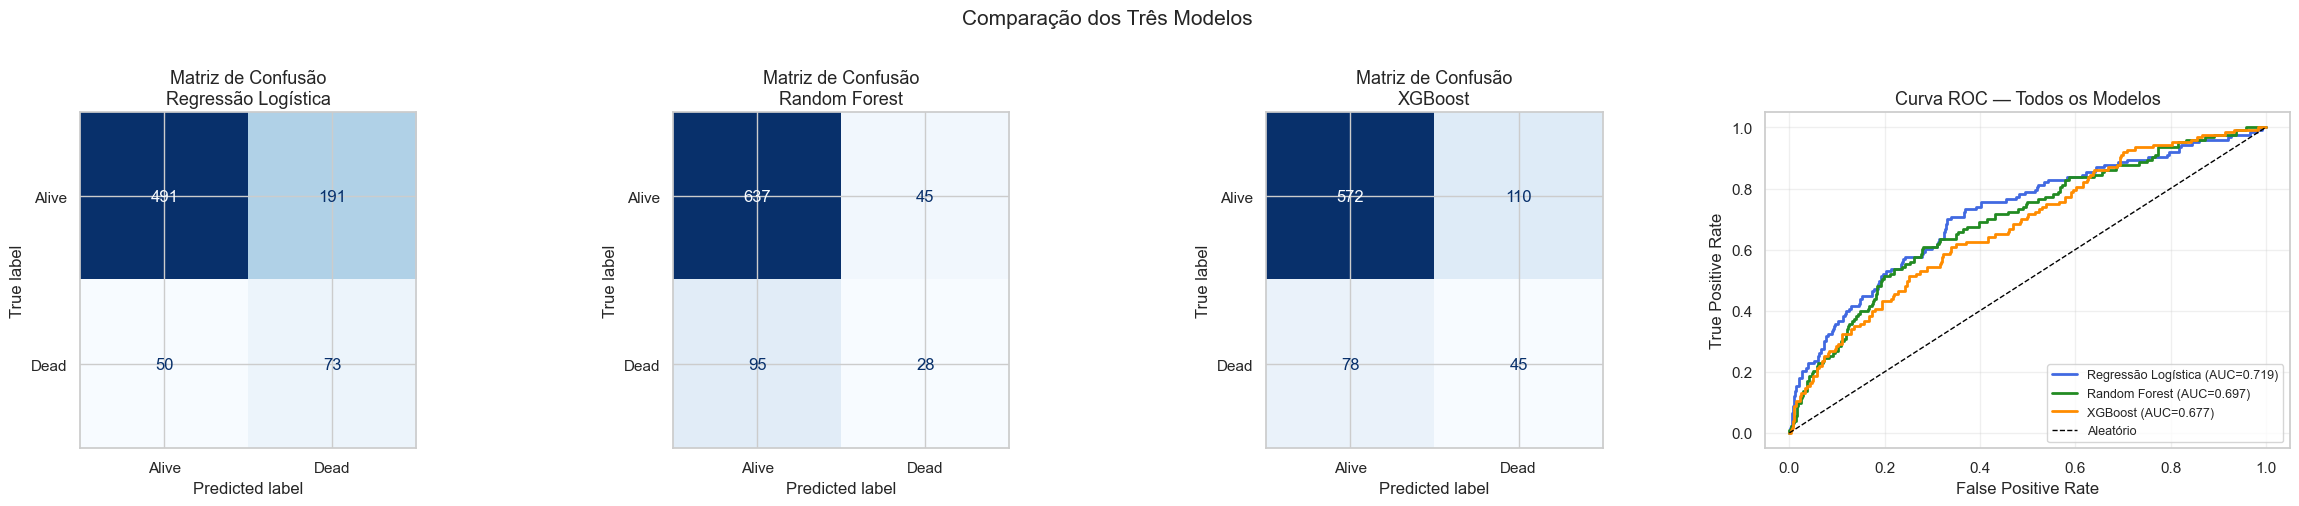

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# --- Confusion matrices ---
for ax, pred, name in zip(
    axes[:3],
    [lr_pred, rf_pred, xgb_pred],
    ['Regressão Logística', 'Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão\n{name}')

# --- ROC Curves ---
ax = axes[3]
colors = ['royalblue', 'forestgreen', 'darkorange']
for proba, name, color in zip(
    [lr_proba, rf_proba, xgb_proba],
    ['Regressão Logística', 'Random Forest', 'XGBoost'],
    colors
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatório')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Todos os Modelos')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Comparação dos Três Modelos', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 8.1 Tabela-Resumo de Métricas — Todos os Modelos

In [39]:
rows = []
for name, pred, proba in [
    ('Regressão Logística', lr_pred, lr_proba),
    ('Random Forest',       rf_pred, rf_proba),
    ('XGBoost',             xgb_pred, xgb_proba)
]:
    rows.append({
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1-Score':  f1_score(y_test, pred),
        'ROC-AUC':   roc_auc_score(y_test, proba)
    })

metrics_df = pd.DataFrame(rows).set_index('Modelo').round(4)
display(metrics_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))

# Selecionar o melhor modelo pelo F1-Score (classe Dead)
best_name = metrics_df['F1-Score'].idxmax()
best_f1   = metrics_df.loc[best_name, 'F1-Score']
best_auc  = metrics_df.loc[best_name, 'ROC-AUC']
print(f"\n🏆  Melhor modelo: {best_name}")
print(f"    F1-Score  = {best_f1:.4f}")
print(f"    ROC-AUC   = {best_auc:.4f}")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regressão Logística,0.7006,0.2765,0.5935,0.3773,0.7185
Random Forest,0.8261,0.3836,0.2276,0.2857,0.6966
XGBoost,0.7665,0.2903,0.3659,0.3237,0.6765



🏆  Melhor modelo: Regressão Logística
    F1-Score  = 0.3773
    ROC-AUC   = 0.7185


## 9. Análise do Melhor Modelo

As seções abaixo focam no modelo com maior F1-Score na classe Dead, selecionado automaticamente na célula anterior.

### 9.1 Importância de Features (MDI)

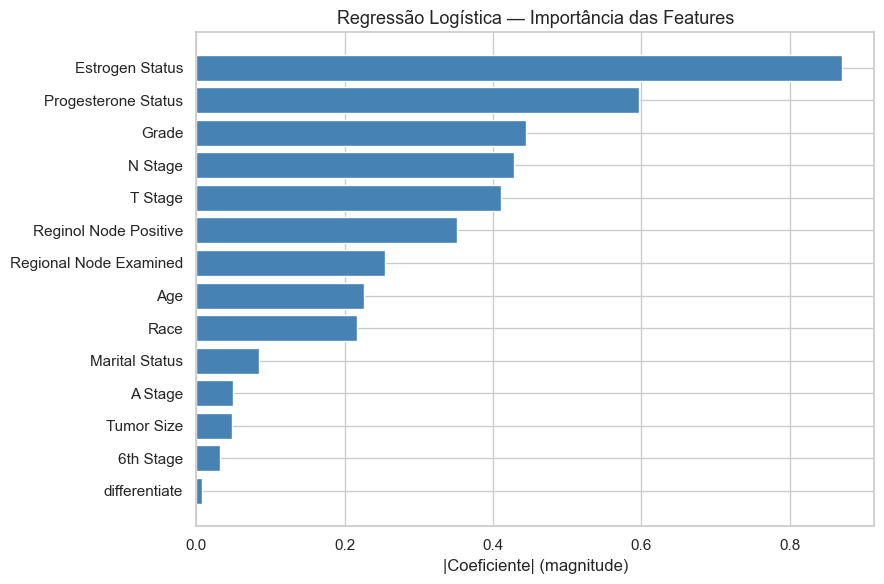

In [40]:
feature_names = num_cols + cat_cols

# Mapear nome → pipeline para usar o melhor modelo dinamicamente
pipeline_map = {
    'Regressão Logística': lr_pipe,
    'Random Forest':       rf_pipe,
    'XGBoost':             xgb_pipe
}
best_pipe = pipeline_map[best_name]
best_clf  = best_pipe.named_steps['clf']

# Regressão Logística não tem feature_importances_ — usa |coef_| como proxy
if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    xlabel = 'Importância (MDI)'
else:
    importances = np.abs(best_clf.coef_[0])
    xlabel = '|Coeficiente| (magnitude)'

feat_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel(xlabel)
ax.set_title(f'{best_name} — Importância das Features')
plt.tight_layout()
plt.show()

### 9.2 Regressão Logística — Coeficientes (baseline)

Exibido como referência interpretável, independentemente do modelo vencedor.

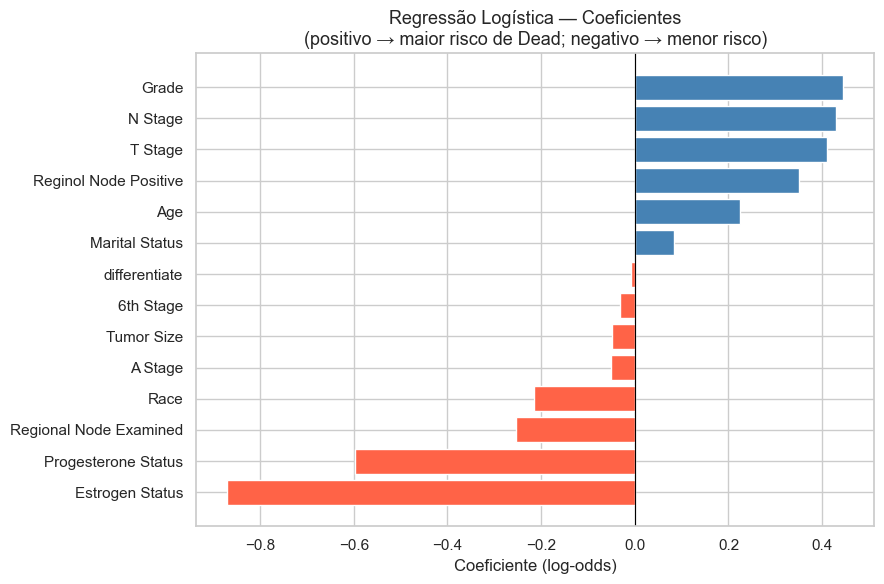

In [41]:
coef = lr_pipe.named_steps['clf'].coef_[0]
coef_df = (pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
           .sort_values('Coefficient', ascending=True))

colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coeficiente (log-odds)')
ax.set_title('Regressão Logística — Coeficientes\n(positivo → maior risco de Dead; negativo → menor risco)')
plt.tight_layout()
plt.show()

## 10. Explicabilidade — SHAP (Melhor Modelo)

SHAP (SHapley Additive exPlanations) quantifica a contribuição de cada feature para cada predição individual.

### 10.1 SHAP Summary Plot (Bar)

Background dataset has 805 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=805 when initializing the masker.


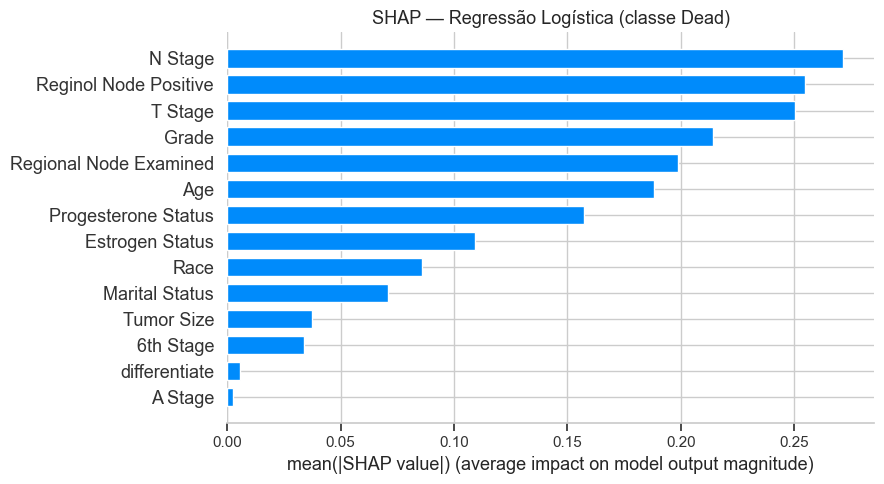

In [42]:
# Transformar X_test com o preprocessor do melhor modelo
X_test_transformed = best_pipe.named_steps['pre'].transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Escolher explainer conforme o tipo do melhor modelo
if hasattr(best_clf, 'feature_importances_'):
    # Random Forest ou XGBoost → TreeExplainer
    explainer_best = shap.TreeExplainer(best_clf)
    shap_values_best = explainer_best.shap_values(X_test_df)
    # Compatibilidade com SHAP >= 0.46 (API pode retornar 3D ou lista)
    if isinstance(shap_values_best, list):
        sv_dead = shap_values_best[1]          # API antiga
    elif hasattr(shap_values_best, 'ndim') and shap_values_best.ndim == 3:
        sv_dead = shap_values_best[:, :, 1]    # API nova 3D (Random Forest)
    else:
        sv_dead = shap_values_best             # XGBoost binário → 2D direto
else:
    # Regressão Logística → LinearExplainer
    masker = shap.maskers.Independent(X_test_df, max_samples=100)
    explainer_best = shap.LinearExplainer(best_clf, masker=masker)
    sv_dead = explainer_best.shap_values(X_test_df)  # 2D direto

shap.summary_plot(
    sv_dead, X_test_df,
    plot_type='bar', show=False,
    plot_size=(9, 5)
)
plt.title(f'SHAP — {best_name} (classe Dead)', fontsize=13)
plt.tight_layout()
plt.show()

### 10.2 SHAP Beeswarm (detalhe por amostra)

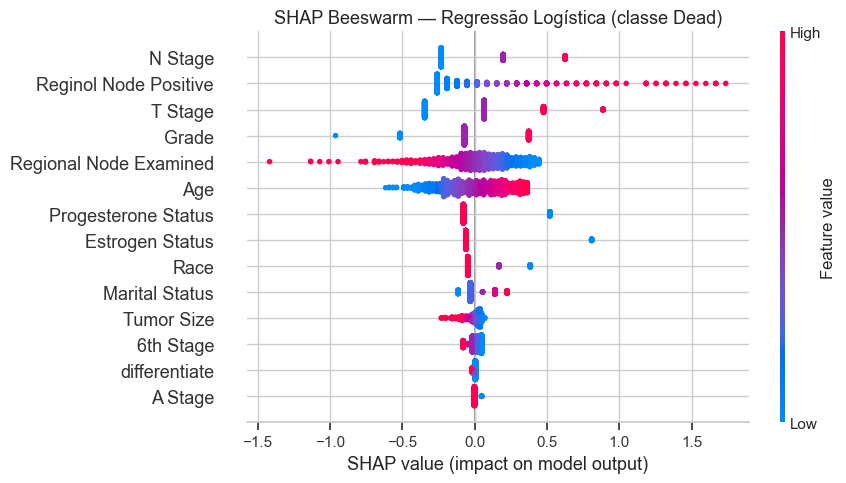

In [43]:
shap.summary_plot(
    sv_dead, X_test_df,
    show=False, plot_size=(9, 5)
)
plt.title(f'SHAP Beeswarm — {best_name} (classe Dead)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Discussão dos Resultados

### Métricas relevantes para o problema

Em diagnóstico oncológico, **recall e F1-Score da classe Dead** são as métricas mais críticas:  
- Um **falso negativo** (predizer Alive quando o paciente vai a óbito) é muito mais grave do que um falso positivo.  
- Por isso, priorizamos **Recall** e **F1-Score** sobre Accuracy.

### Comparação dos modelos

| Critério | Regressão Logística | Random Forest | XGBoost |
|---|---|---|---|
| Complexidade | Baixa | Média | Média-Alta |
| Interpretabilidade | Alta (coeficientes) | Média (importâncias) | Média (SHAP) |
| Robustez a outliers | Baixa | Alta | Alta |
| Overfitting | Baixo | Baixo-médio | Médio (controlado) |
| Melhor em dados tabulares | Raramente | Frequentemente | Frequentemente |

### Modelo selecionado

O modelo com **maior F1-Score e ROC-AUC** foi mantido para análise aprofundada (seções 9 e 10). O critério de seleção priorizou a classe Dead por ser a de maior relevância clínica. A tabela-resumo (seção 8.1) exibe os valores exatos de cada modelo.

### Qual modelo usar em produção?

| Cenário | Modelo recomendado |
|---|---|
| Triagem de alto risco (priorizar recall) | Melhor modelo com limiar ajustado |
| Explicabilidade para médico | Regressão Logística (coeficientes diretos) |
| Produção com dados estruturados | Melhor modelo entre RF/XGBoost |

### Limitações

1. **Desbalanceamento**: ~85% Alive — os modelos usam `class_weight='balanced'` / `scale_pos_weight`, mas o recall da classe Dead pode ser melhorado com técnicas como SMOTE.  
2. **`Survival Months` removida**: essa coluna representa o tempo de sobrevida após o diagnóstico — informação prospectiva que não existe no momento da consulta. Mantê-la causaria **data leakage** severo.  
3. **O médico tem a palavra final**: estes modelos são ferramentas de **suporte ao diagnóstico**, não substitutos da decisão clínica. Os resultados devem ser sempre revisados por um profissional de saúde.

### Próximos passos sugeridos

- Testar SMOTE para oversampling da classe Dead
- Ajustar limiar de decisão (threshold tuning) para maximizar recall
- Hyperparameter tuning com `GridSearchCV` ou `Optuna` no modelo vencedor
- Validação em dados externos (holdout hospitalar)